In [1]:
import sys, os
import pandas as pd
import numpy as np

sys.path.append("..")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

DATA_PATH = os.path.join("..", "data", "raw", "mental-heath-in-tech-2016_20161114.csv")
df = pd.read_csv(DATA_PATH)

In [2]:
from src import feature_config
from src.preprocessing import (
    run_pipeline, prepare_for_feature_selection,
    impute_structural_missingness, fill_remaining_with_mean,
)
from src.feature_selection import (
    apply_chi_square, apply_mutual_information,
    apply_variance_threshold, apply_correlation_filter,
)

df_processed = run_pipeline(df, feature_config)

df_imputed = impute_structural_missingness(df_processed, feature_config.STRUCTURAL_MISSINGNESS)
df_imputed = fill_remaining_with_mean(df_imputed, exclude_cols=["age_group"])

print("Shape after pipeline + imputation:", df_imputed.shape)

negative_impact_reveal: 75 rows answered despite reveal_to_clients_direction==2
negative_impact_reveal_coworker: 30 rows answered despite reveal_to_coworkers_direction==2
percentage_affected: 38 rows answered despite productivity_affected==1
Shape after pipeline + imputation: (1433, 183)


In [3]:
df_selection_ready = prepare_for_feature_selection(df, feature_config)

chi_square_results = apply_chi_square(df_selection_ready, feature_config.FEATURE_FILTER_GROUPS)
mi_results = apply_mutual_information(df_selection_ready, feature_config.FEATURE_FILTER_GROUPS)

In [4]:
variance_threshold_results = apply_variance_threshold(df_imputed)
corr_matrix, high_corr_features = apply_correlation_filter(df_imputed, threshold=0.7)

In [ ]:
columns_to_drop_variance = variance_threshold_results.loc[
    variance_threshold_results["kept"] == False, "feature"
].tolist()
columns_to_drop_variance.remove("reveal_to_clients_direction")  # override: imputation artifact, see DECISIONS.md

condition_dupes_to_drop = [
    "diagnosed_conditions__attention_deficit_hyperactivity_disorder",
    "diagnosed_conditions__obsessive_compulsive_disorder",
    "diagnosed_conditions__autism",
    "diagnosed_conditions__anxiety_disorder",
    "diagnosed_conditions__psychotic_disorder",
    "diagnosed_conditions__mood_disorder",
    "diagnosed_conditions__burn_out",
    "diagnosed_conditions__post_traumatic_stress_disorder",
    "diagnosed_conditions__eating_disorder",
    "diagnosed_conditions__dissociative_disorder",
]

columns_to_drop = (
    columns_to_drop_variance
    + ["gender_cleaned_female"]
    + condition_dupes_to_drop
    + ["age_group"]
)

In [6]:
df_final = df_imputed.drop(columns=columns_to_drop, errors="ignore")

print("Shape before drop:", df_imputed.shape)
print("Shape after drop:", df_final.shape)
print("Remaining NaN:", df_final.isnull().sum().sum())

non_numeric = df_final.dtypes[~df_final.dtypes.apply(pd.api.types.is_numeric_dtype)]
print("Non-numeric columns:", list(non_numeric.index))

Shape before drop: (1433, 183)
Shape after drop: (1433, 151)
Remaining NaN: 0
Non-numeric columns: []


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_final.columns, index=df_final.index)
X_scaled_df.shape

(1433, 151)

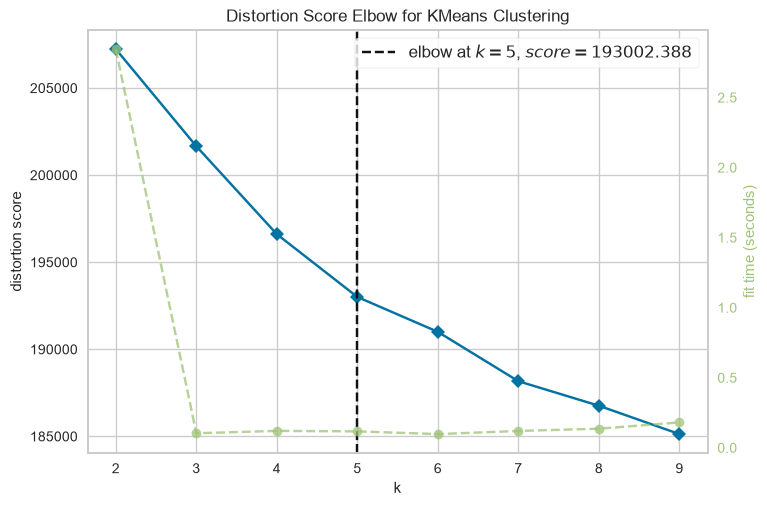

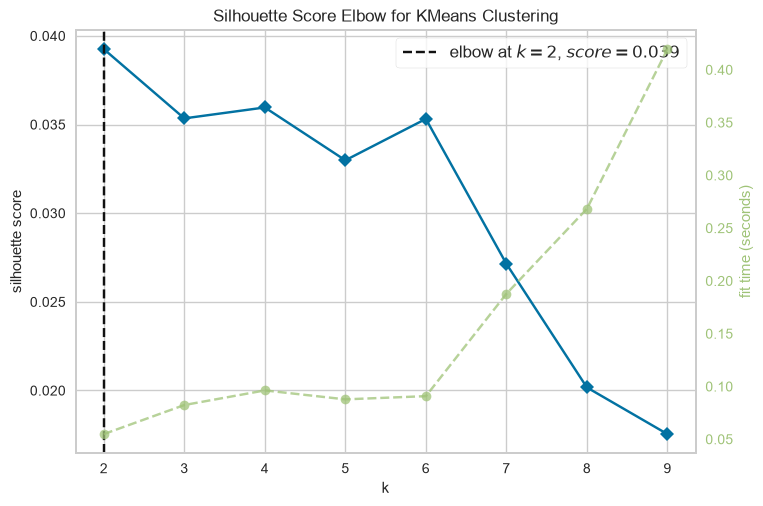

Elbow (distortion) suggests k = 5
Elbow (silhouette) suggests k = 2


In [8]:
from src.clustering import plot_elbow_method

viz_distortion = plot_elbow_method(X_scaled_df, max_k=10, metric='distortion')
viz_silhouette = plot_elbow_method(X_scaled_df, max_k=10, metric='silhouette')

print("Elbow (distortion) suggests k =", viz_distortion.elbow_value_)
print("Elbow (silhouette) suggests k =", viz_silhouette.elbow_value_)

In [9]:
from src.clustering import compute_gower_distance_matrix, perform_hierarchical_clustering, plot_dendrogram

numeric_cols = ["age"] + [c for c in feature_config.ORDINAL_COLUMNS if c in df_final.columns]
distance_matrix = compute_gower_distance_matrix(df_final, numeric_cols)

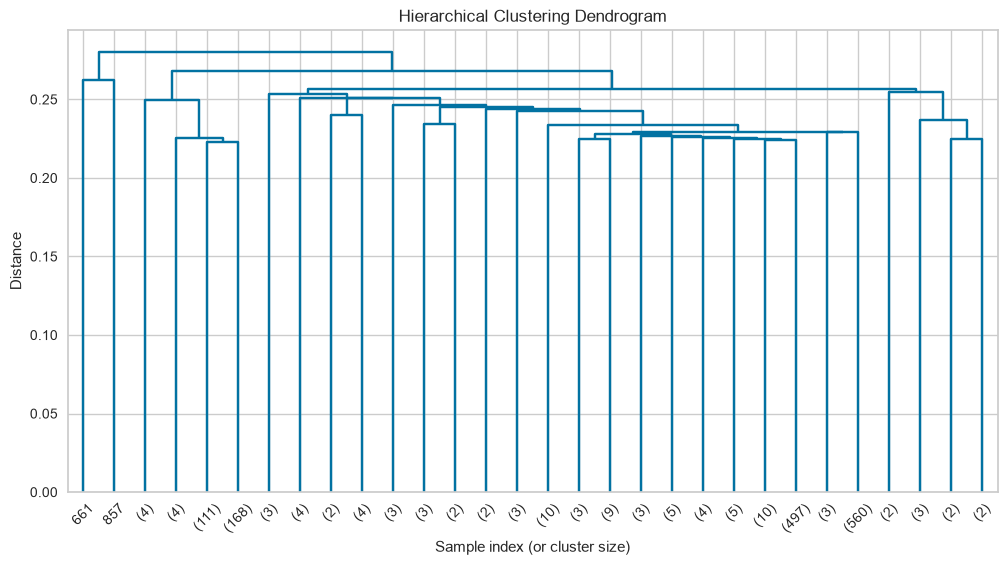

In [11]:
Z, gower_labels = perform_hierarchical_clustering(distance_matrix, n_clusters=4, linkage_method='average')
plot_dendrogram(Z)

In [12]:
from sklearn.metrics import silhouette_score
score = silhouette_score(distance_matrix, gower_labels, metric='precomputed')
print("Gower + hierarchical silhouette:", score)

Gower + hierarchical silhouette: 0.15377910435199738


In [13]:
df_gower_profile = df_final.drop(columns=["cluster"], errors="ignore").copy()
df_gower_profile["cluster"] = gower_labels

cluster_summary = df_gower_profile.groupby("cluster").mean(numeric_only=True)
cluster_sizes = df_gower_profile["cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)
print()
cluster_summary

Cluster sizes:
cluster
1       1
2       1
3     287
4    1144
Name: count, dtype: int64



,self_employed,tech_company,awareness_mental_health_care,formal_mental_health_discussion,mental_health_resources,anonymity_protected,medical_leave_request,negative_consequences_discussion,negative_consequences_physical_health,comfortable_discussing_with_coworkers,comfortable_discussing_with_supervisor,employer_takes_mental_health_seriously,negative_consequences_open_about_mental_health,medical_coverage,awareness_resources,negative_impact_reveal,negative_impact_reveal_coworker,productivity_affected,percentage_affected,previous_employers,previous_employers_mental_health_benefits,awareness_previous_employers,previous_employers_mental_health_discussion,previous_employers_resources,previous_employers_anonymity_protected,previous_employers_negative_consequences,previous_employers_negative_consequences_physical,previous_employers_comfortable_discussing_coworkers,previous_employers_comfortable_discussing_supervisor,previous_employers_mental_health_seriously,previous_employers_negative_consequences_coworkers,potential_employer_physical_health,potential_employer_mental_health,willingness_share_mental_illness,less_likely_reveal_mental_health,family_history_mental_illness,past_mental_health_disorder,current_mental_health_disorder,diagnosed_by_professional,sought_treatment,interferes_with_work_treated,interferes_with_work_not_treated,age,works_remotely,diagnosed_conditions__addictive_disorder,diagnosed_conditions__adjustment_disorder,diagnosed_conditions__eating_disorder,diagnosed_conditions__personality_disorder,diagnosed_conditions__post_traumatic_stress_disorder,believed_conditions__addictive_disorder,believed_conditions__adjustment_disorder,believed_conditions__anxiety_disorder,believed_conditions__attention_deficit_hyperactivity_disorder,believed_conditions__mood_disorder,believed_conditions__obsessive_compulsive_disorder,believed_conditions__personality_disorder,believed_conditions__post_traumatic_stress_disorder,diagnosed_conditions_professional__addictive_disorder,diagnosed_conditions_professional__adjustment_disorder,diagnosed_conditions_professional__anxiety_disorder,diagnosed_conditions_professional__attention_deficit_hyperactivity_disorder,diagnosed_conditions_professional__eating_disorder,diagnosed_conditions_professional__mood_disorder,diagnosed_conditions_professional__obsessive_compulsive_disorder,diagnosed_conditions_professional__personality_disorder,diagnosed_conditions_professional__post_traumatic_stress_disorder,work_position__back_end_developer,work_position__designer,work_position__dev_evangelist_advocate,work_position__devops_sysadmin,work_position__executive_leadership,work_position__front_end_developer,work_position__one_person_shop,work_position__other,work_position__sales,work_position__supervisor_team_lead,work_position__support,reason_not_willing_physical_health__job_relevance_impact,reason_not_willing_physical_health__fear_hiring_risk,reason_not_willing_physical_health__discrimination_stigma,reason_not_willing_physical_health__privacy_personal,reason_not_willing_physical_health__honesty_trust,reason_not_willing_physical_health__accommodation_disability,reason_not_willing_physical_health__timing_later,reason_not_willing_physical_health__not_applicable,reason_not_willing_physical_health__productivity_performance,reason_not_willing_mental_health__job_relevance_impact,reason_not_willing_mental_health__fear_hiring_risk,reason_not_willing_mental_health__discrimination_stigma,reason_not_willing_mental_health__privacy_personal,reason_not_willing_mental_health__honesty_trust,reason_not_willing_mental_health__accommodation_disability,reason_not_willing_mental_health__not_applicable,reason_not_willing_mental_health__productivity_performance,reason_not_willing_mental_health__understanding_support,reveal_to_coworkers_direction,reveal_to_clients_direction,career_impact_mental_health_direction,team_view_mental_health_direction,unsupportive_response_mental_health_direction,company_size_26_100,company_size_6_25,company_size_m

In [14]:
self_employed_gated_cols = [
    "tech_company", "tech_role", "mental_health_benefits",
    "awareness_mental_health_care", "formal_mental_health_discussion",
    "mental_health_resources", "anonymity_protected", "medical_leave_request",
    "negative_consequences_discussion", "negative_consequences_physical_health",
    "comfortable_discussing_with_coworkers", "comfortable_discussing_with_supervisor",
    "employer_takes_mental_health_seriously", "negative_consequences_open_about_mental_health",
    "medical_coverage", "awareness_resources",
]

X_gower_retry = df_final.drop(columns=["self_employed", "cluster"] + self_employed_gated_cols, errors="ignore")
numeric_cols_retry = ["age"] + [c for c in feature_config.ORDINAL_COLUMNS if c in X_gower_retry.columns]

distance_matrix_retry = compute_gower_distance_matrix(X_gower_retry, numeric_cols_retry)
Z_retry, gower_labels_retry = perform_hierarchical_clustering(distance_matrix_retry, n_clusters=4)

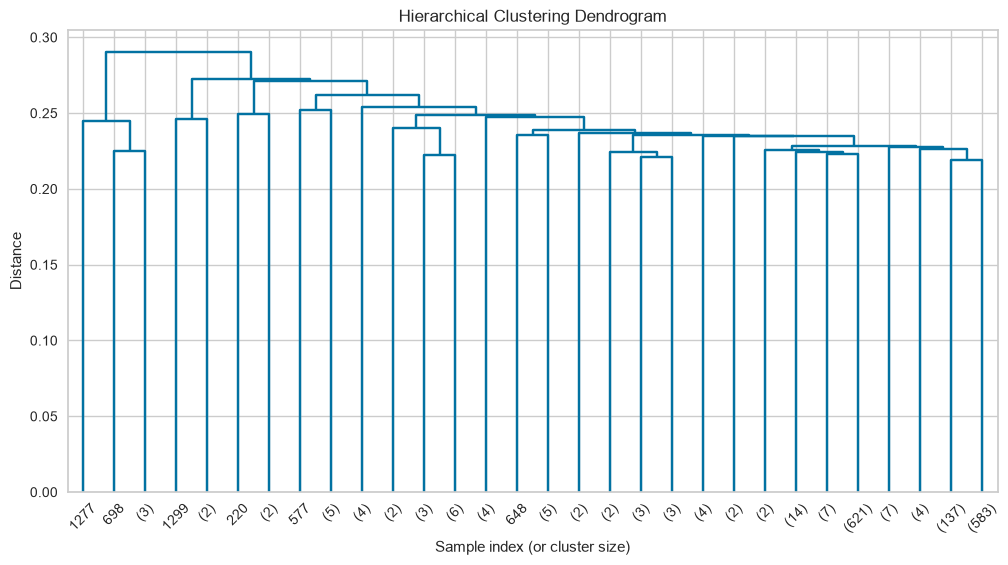

In [15]:
#Z_retry, gower_labels_retry = perform_hierarchical_clustering(distance_matrix_retry, n_clusters=4, linkage_method='average')
plot_dendrogram(Z_retry)

In [16]:
from sklearn.metrics import silhouette_score
score = silhouette_score(distance_matrix_retry, gower_labels_retry, metric='precomputed')
print("Gower + hierarchical silhouette:", score)

Gower + hierarchical silhouette: 0.16200560331344604


In [17]:
df_gower_profile_retry = df_final.drop(columns=["cluster"], errors="ignore").copy()
df_gower_profile_retry["cluster"] = gower_labels_retry

cluster_summary_retry = df_gower_profile_retry.groupby("cluster").mean(numeric_only=True)
cluster_sizes_retry = df_gower_profile_retry["cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes_retry)
print()
cluster_summary_retry

Cluster sizes:
cluster
1       5
2       3
3       3
4    1422
Name: count, dtype: int64



,self_employed,tech_company,awareness_mental_health_care,formal_mental_health_discussion,mental_health_resources,anonymity_protected,medical_leave_request,negative_consequences_discussion,negative_consequences_physical_health,comfortable_discussing_with_coworkers,comfortable_discussing_with_supervisor,employer_takes_mental_health_seriously,negative_consequences_open_about_mental_health,medical_coverage,awareness_resources,negative_impact_reveal,negative_impact_reveal_coworker,productivity_affected,percentage_affected,previous_employers,previous_employers_mental_health_benefits,awareness_previous_employers,previous_employers_mental_health_discussion,previous_employers_resources,previous_employers_anonymity_protected,previous_employers_negative_consequences,previous_employers_negative_consequences_physical,previous_employers_comfortable_discussing_coworkers,previous_employers_comfortable_discussing_supervisor,previous_employers_mental_health_seriously,previous_employers_negative_consequences_coworkers,potential_employer_physical_health,potential_employer_mental_health,willingness_share_mental_illness,less_likely_reveal_mental_health,family_history_mental_illness,past_mental_health_disorder,current_mental_health_disorder,diagnosed_by_professional,sought_treatment,interferes_with_work_treated,interferes_with_work_not_treated,age,works_remotely,diagnosed_conditions__addictive_disorder,diagnosed_conditions__adjustment_disorder,diagnosed_conditions__eating_disorder,diagnosed_conditions__personality_disorder,diagnosed_conditions__post_traumatic_stress_disorder,believed_conditions__addictive_disorder,believed_conditions__adjustment_disorder,believed_conditions__anxiety_disorder,believed_conditions__attention_deficit_hyperactivity_disorder,believed_conditions__mood_disorder,believed_conditions__obsessive_compulsive_disorder,believed_conditions__personality_disorder,believed_conditions__post_traumatic_stress_disorder,diagnosed_conditions_professional__addictive_disorder,diagnosed_conditions_professional__adjustment_disorder,diagnosed_conditions_professional__anxiety_disorder,diagnosed_conditions_professional__attention_deficit_hyperactivity_disorder,diagnosed_conditions_professional__eating_disorder,diagnosed_conditions_professional__mood_disorder,diagnosed_conditions_professional__obsessive_compulsive_disorder,diagnosed_conditions_professional__personality_disorder,diagnosed_conditions_professional__post_traumatic_stress_disorder,work_position__back_end_developer,work_position__designer,work_position__dev_evangelist_advocate,work_position__devops_sysadmin,work_position__executive_leadership,work_position__front_end_developer,work_position__one_person_shop,work_position__other,work_position__sales,work_position__supervisor_team_lead,work_position__support,reason_not_willing_physical_health__job_relevance_impact,reason_not_willing_physical_health__fear_hiring_risk,reason_not_willing_physical_health__discrimination_stigma,reason_not_willing_physical_health__privacy_personal,reason_not_willing_physical_health__honesty_trust,reason_not_willing_physical_health__accommodation_disability,reason_not_willing_physical_health__timing_later,reason_not_willing_physical_health__not_applicable,reason_not_willing_physical_health__productivity_performance,reason_not_willing_mental_health__job_relevance_impact,reason_not_willing_mental_health__fear_hiring_risk,reason_not_willing_mental_health__discrimination_stigma,reason_not_willing_mental_health__privacy_personal,reason_not_willing_mental_health__honesty_trust,reason_not_willing_mental_health__accommodation_disability,reason_not_willing_mental_health__not_applicable,reason_not_willing_mental_health__productivity_performance,reason_not_willing_mental_health__understanding_support,reveal_to_coworkers_direction,reveal_to_clients_direction,career_impact_mental_health_direction,team_view_mental_health_direction,unsupportive_response_mental_health_direction,company_size_26_100,company_size_6_25,company_size_m

In [8]:
Z_complete, labels_complete = perform_hierarchical_clustering(distance_matrix, n_clusters=4, linkage_method='complete')
print(pd.Series(labels_complete).value_counts().sort_index())

1    287
2    501
3    181
4    464
Name: count, dtype: int64


In [10]:
from sklearn.metrics import silhouette_score

score_complete = silhouette_score(distance_matrix, labels_complete, metric='precomputed')
print("Gower + complete linkage silhouette:", score_complete)

Gower + complete linkage silhouette: 0.10233698040246964


In [11]:
core_attitude_cols = [
    "age", "sought_treatment", "diagnosed_by_professional",
    "past_mental_health_disorder", "current_mental_health_disorder",
    "willingness_share_mental_illness",
    "comfortable_discussing_with_coworkers", "comfortable_discussing_with_supervisor",
    "career_impact_mental_health_direction", "team_view_mental_health_direction",
    "family_history_mental_illness",
    "negative_consequences_discussion", "negative_consequences_physical_health",
    "potential_employer_physical_health", "potential_employer_mental_health",
    "reveal_to_coworkers_direction", "reveal_to_clients_direction",
]
core_attitude_cols = [c for c in core_attitude_cols if c in df_final.columns]

X_core = df_final[core_attitude_cols].copy()
numeric_cols_core = ["age"] + [c for c in feature_config.ORDINAL_COLUMNS if c in X_core.columns]

distance_matrix_core = compute_gower_distance_matrix(X_core, numeric_cols_core)

Z_core, labels_core = perform_hierarchical_clustering(distance_matrix_core, n_clusters=4, linkage_method='complete')
score_core = silhouette_score(distance_matrix_core, labels_core, metric='precomputed')
print("Core-features silhouette:", score_core)
print(pd.Series(labels_core).value_counts().sort_index())

Core-features silhouette: 0.14766666293144226
1    279
2    439
3    159
4    556
Name: count, dtype: int64


In [10]:
for k in [2, 3, 4, 5, 6]:
    _, labels_k = perform_hierarchical_clustering(distance_matrix, n_clusters=k, linkage_method='complete')
    score_k = silhouette_score(distance_matrix, labels_k, metric='precomputed')
    print(f"k={k}: silhouette={score_k:.4f}")

k=2: silhouette=0.1999
k=3: silhouette=0.1280
k=4: silhouette=0.1023
k=5: silhouette=0.0820
k=6: silhouette=0.0815


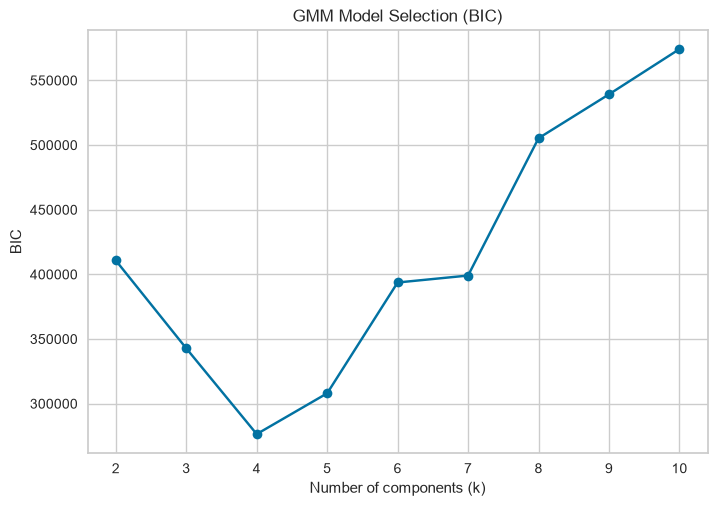

BIC suggests k = 4
GMM k=2: silhouette=0.0687
GMM k=3: silhouette=0.0387
GMM k=4: silhouette=0.0352
GMM k=5: silhouette=0.0322


In [8]:
from src.clustering import plot_gmm_bic_scan, perform_gmm_clustering
from sklearn.metrics import silhouette_score

bic_scores = plot_gmm_bic_scan(X_scaled_df, max_k=10)
best_k_bic = min(bic_scores, key=bic_scores.get)
print("BIC suggests k =", best_k_bic)

for k in [2, 3, 4, 5]:
    _, labels_gmm = perform_gmm_clustering(X_scaled_df, n_components=k)
    score = silhouette_score(X_scaled_df, labels_gmm)
    print(f"GMM k={k}: silhouette={score:.4f}")

In [11]:
_, labels_k2 = perform_hierarchical_clustering(distance_matrix, n_clusters=2, linkage_method='complete')
df_check = df_final.copy()
df_check['cluster'] = labels_k2
pd.crosstab(df_check['cluster'], df_check['self_employed'])

self_employed,0,1
cluster,,
1,0,287
2,1146,0


In [8]:
# Lower threshold, systematic pass across the WHOLE matrix
_, low_corr_pairs = apply_correlation_filter(df_imputed, threshold=0.5)
print(len(low_corr_pairs), "pairs above 0.5 correlation")
low_corr_pairs

71 pairs above 0.5 correlation


,feature_a,feature_b,correlation
9182,diagnosed_conditions__burn_out,diagnosed_conditions_professional__burn_out,1.000000
25438,gender_cleaned_male,gender_cleaned_female,-0.926514
30013,reveal_to_clients_special_not_applicable_to_me,reveal_to_coworkers_special_not_applicable_to_me,0.909509
32758,negative_impact_reveal_not_applicable,negative_impact_reveal_coworker_not_applicable,0.828328
32392,interferes_with_work_treated_special_not_applicable_to_me,interferes_with_work_not_treated_special_not_applicable_to_me,0.824498
8816,diagnosed_conditions__attention_deficit_hyperactivity_disorder,diagnosed_conditions_professional__attention_deficit_hyperactivity_disorder,0.798425
7184,diagnosed_by_professional,diagnosed_conditions_professional__mood_disorder,0.766650
30196,reveal_to_coworkers_special_not_applicable_to_me,negative_impact_reveal_coworker_special_not_applicable_to_me,0.761980
10097,diagnosed_conditions__obsessive_compulsive_disorder,diagnosed_conditions_professional__obsessive_compulsive_disorder,0.746790
6773,past_mental_health_disorder,diagnosed_by_professional,0.743473


In [11]:
import networkx as nx

G = nx.Graph()
for _, row in low_corr_pairs.iterrows():
    G.add_edge(row['feature_a'], row['feature_b'], weight=row['correlation'])

redundancy_groups = list(nx.connected_components(G))
redundancy_groups = [g for g in redundancy_groups if len(g) > 1]

print(f"{len(redundancy_groups)} redundancy groups found (avg size: {sum(len(g) for g in redundancy_groups)/len(redundancy_groups):.1f})")
for i, group in enumerate(redundancy_groups):
    print(f"\nGroup {i+1} ({len(group)} columns):")
    print(sorted(group))

23 redundancy groups found (avg size: 3.0)

Group 1 (2 columns):
['diagnosed_conditions__burn_out', 'diagnosed_conditions_professional__burn_out']

Group 2 (2 columns):
['gender_cleaned_female', 'gender_cleaned_male']

Group 3 (11 columns):
['anonymity_protected_special_i_dont_know', 'negative_consequences_open_about_mental_health', 'negative_impact_reveal_coworker_not_applicable', 'negative_impact_reveal_coworker_special_not_applicable_to_me', 'negative_impact_reveal_not_applicable', 'productivity_affected', 'productivity_affected_special_not_applicable_to_me', 'reveal_to_clients_special_not_applicable_to_me', 'reveal_to_coworkers_special_not_applicable_to_me', 'self_employed', 'work_position__one_person_shop']

Group 4 (10 columns):
['current_mental_health_disorder', 'diagnosed_by_professional', 'diagnosed_conditions__anxiety_disorder', 'diagnosed_conditions__mood_disorder', 'diagnosed_conditions_professional__anxiety_disorder', 'diagnosed_conditions_professional__mood_disorder', 'in

In [12]:
ct = pd.crosstab(df_imputed['previous_employers_mental_health_discussion'], df_imputed['previous_employers_resources'])
print((np.trace(ct.values)/ct.values.sum())*100, "% concordant")

79.97208653175157 % concordant


In [13]:
group3 = [g for g in redundancy_groups if 'self_employed' in g][0]
subG = G.subgraph(group3)

for u, v, data in subG.edges(data=True):
    print(f"{u} <-> {v}: {data['weight']:.3f}")

anonymity_protected_special_i_dont_know <-> self_employed: -0.519
negative_consequences_open_about_mental_health <-> self_employed: 0.742
negative_consequences_open_about_mental_health <-> negative_impact_reveal_coworker_not_applicable: -0.514
reveal_to_clients_special_not_applicable_to_me <-> reveal_to_coworkers_special_not_applicable_to_me: 0.910
reveal_to_clients_special_not_applicable_to_me <-> negative_impact_reveal_coworker_special_not_applicable_to_me: 0.711
reveal_to_clients_special_not_applicable_to_me <-> self_employed: 0.550
reveal_to_clients_special_not_applicable_to_me <-> productivity_affected_special_not_applicable_to_me: 0.521
reveal_to_coworkers_special_not_applicable_to_me <-> negative_impact_reveal_coworker_special_not_applicable_to_me: 0.762
reveal_to_coworkers_special_not_applicable_to_me <-> self_employed: 0.579
self_employed <-> negative_impact_reveal_coworker_not_applicable: -0.693
self_employed <-> negative_impact_reveal_not_applicable: -0.668
self_employed <->

In [ ]:
no_disclosure_flags = [
    "reveal_to_clients_special_not_applicable_to_me",
    "reveal_to_coworkers_special_not_applicable_to_me",
    "negative_impact_reveal_not_applicable",
    "negative_impact_reveal_coworker_not_applicable",
    "negative_impact_reveal_coworker_special_not_applicable_to_me",
    "productivity_affected_special_not_applicable_to_me",
]
df_final["no_disclosure_history"] = (df_imputed[no_disclosure_flags].sum(axis=1) > 0).astype(int)
# then drop all six originals

In [16]:
from src.clustering import perform_hierarchical_clustering, compute_gower_distance_matrix
from sklearn.metrics import silhouette_score

structural_flag_suffixes = ("_special", "_not_applicable")
attitude_cols = [c for c in df_final.columns if not c.endswith(structural_flag_suffixes)]

X_attitude = df_final[attitude_cols].copy()
numeric_cols_attitude = ["age"] + [c for c in feature_config.ORDINAL_COLUMNS if c in X_attitude.columns]

distance_matrix_attitude = compute_gower_distance_matrix(X_attitude, numeric_cols_attitude)

print(f"Attitude-only feature set: {X_attitude.shape[1]} columns (down from {df_final.shape[1]})")

for k in [2, 3, 4, 5, 6]:
    _, labels_k = perform_hierarchical_clustering(distance_matrix_attitude, n_clusters=k, linkage_method='complete')
    score_k = silhouette_score(distance_matrix_attitude, labels_k, metric='precomputed')
    print(f"k={k}: silhouette={score_k:.4f}")

Attitude-only feature set: 147 columns (down from 151)
k=2: silhouette=0.1842
k=3: silhouette=0.1324
k=4: silhouette=0.0930
k=5: silhouette=0.0579
k=6: silhouette=0.0444


In [19]:
def is_structural_flag(col):
    return "_special_" in col or col.endswith("_not_applicable") or col.endswith("_special")

structural_flag_cols = [c for c in df_final.columns if is_structural_flag(c)]
attitude_cols = [c for c in df_final.columns if not is_structural_flag(c)]

print(f"Structural flags found: {len(structural_flag_cols)}")
print(structural_flag_cols)
print(f"\nAttitude-only feature set: {len(attitude_cols)} columns (down from {df_final.shape[1]})")

Structural flags found: 24
['reason_not_willing_physical_health__not_applicable', 'reason_not_willing_mental_health__not_applicable', 'formal_mental_health_discussion_special_i_dont_know', 'mental_health_resources_special_i_dont_know', 'anonymity_protected_special_i_dont_know', 'medical_leave_request_special_i_dont_know', 'employer_takes_mental_health_seriously_special_i_dont_know', 'reveal_to_clients_special_not_applicable_to_me', 'reveal_to_coworkers_special_not_applicable_to_me', 'negative_impact_reveal_coworker_special_not_applicable_to_me', 'productivity_affected_special_not_applicable_to_me', 'previous_employers_mental_health_benefits_special_i_dont_know', 'awareness_previous_employers_special_n_a_not_currently_aware', 'previous_employers_mental_health_discussion_special_i_dont_know', 'previous_employers_anonymity_protected_special_i_dont_know', 'previous_employers_negative_consequences_special_i_dont_know', 'previous_employers_comfortable_discussing_supervisor_special_i_dont_kno

In [20]:
X_attitude = df_final[attitude_cols].copy()
numeric_cols_attitude = ["age"] + [c for c in feature_config.ORDINAL_COLUMNS if c in X_attitude.columns]

distance_matrix_attitude = compute_gower_distance_matrix(X_attitude, numeric_cols_attitude)

for k in [2, 3, 4, 5, 6]:
    _, labels_k = perform_hierarchical_clustering(distance_matrix_attitude, n_clusters=k, linkage_method='complete')
    score_k = silhouette_score(distance_matrix_attitude, labels_k, metric='precomputed')
    print(f"k={k}: silhouette={score_k:.4f}")

k=2: silhouette=0.1842
k=3: silhouette=0.1109
k=4: silhouette=0.0961
k=5: silhouette=0.0540
k=6: silhouette=0.0518


In [21]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

from src.clustering import perform_kmeans_clustering

_, labels_km = perform_kmeans_clustering(X_scaled_df, n_clusters=4)
print("DB:", davies_bouldin_score(X_scaled_df, labels_km))
print("CH:", calinski_harabasz_score(X_scaled_df, labels_km))

DB: 3.9581486276979203
CH: 47.90922073968863
